# Ionosphere Eval — Persistence vs Climatology vs OMNI-GRU vs Flat CNN vs SFNO

Loads all four trained checkpoints + the two no-training baselines, scores them on a shared held-out
split, and reports: weighted RMSE per horizon, skill vs. persistence (%), R² / variance explained (%),
pooled spatial correlation, and a storm/quiet (Kp) breakdown per model (kept as separate breakdowns
per project convention, not crossed with anything else).

**On "% accuracy":** this is regression (continuous dTEC maps), not classification, so there's no
natural "% correct." Two real percentage-style numbers are reported instead:
- **Skill score vs. persistence** = `(1 - RMSE_model / RMSE_persistence) * 100%` — the standard way
  to express "how much better than the naive baseline."
- **R² (variance explained)** = `100% * (1 - SS_res/SS_tot)` — complementary, answers "how much of
  the true signal's variance does the model actually capture."

**Absolute-TEC / climatology section (Cell 12)** uses Hayden's per-year `.npz` delivery — grid,
units, and join method are confirmed (see Cell 12), one detail (what `tec` represents) is still
pending one direct answer from Hayden.


## Cell 1 — Setup: mount Drive, copy data locally, install, imports, GPU check

Same pattern as `ionosphere_baselines.ipynb` / `ionosphere_s2cnn.ipynb` (self-contained, no manual
upload step needed).


In [1]:
from google.colab import drive
drive.mount('/content/drive')

import shutil, os, json, warnings
from pathlib import Path

DRIVE_DATA_DIR = "/content/drive/MyDrive/tec_data/new_data"
LOCAL_DATA_DIR = "new_data"
CKPT_DIR       = "/content/drive/MyDrive/tec_data"   # checkpoints loaded directly from Drive, not copied

os.makedirs(LOCAL_DATA_DIR, exist_ok=True)
for fname in os.listdir(DRIVE_DATA_DIR):
    if fname.endswith('.npy') or fname.endswith('.json'):
        dst = os.path.join(LOCAL_DATA_DIR, fname)
        if not os.path.exists(dst):
            shutil.copy(os.path.join(DRIVE_DATA_DIR, fname), dst)
print("Local data files:", sorted(os.listdir(LOCAL_DATA_DIR)))

!pip install -q torch-harmonics

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from torch_harmonics.quadrature import legendre_gauss_weights
from torch_harmonics import RealSHT, InverseRealSHT

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')
if DEVICE.type == 'cpu':
    print('WARNING: No GPU detected. Runtime -> Change runtime type -> T4 GPU')


Mounted at /content/drive
Local data files: ['lats.npy', 'lons.npy', 'metadata.json', 'test_omni_input.npy', 'test_target.npy', 'test_tec_input.npy', 'test_window_start_times.npy', 'train_omni_input.npy', 'train_target.npy', 'train_tec_input.npy', 'train_window_start_times.npy', 'val_omni_input.npy', 'val_target.npy', 'val_tec_input.npy', 'val_window_start_times.npy']
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 537.6/537.6 kB 36.6 MB/s eta 0:00:00
Using device: cuda


## Cell 2 — Config

Same metadata-driven values as the other two notebooks. `flip_latitude=False` is the confirmed
value (see handoff doc / `ionosphere_s2cnn.ipynb` Cell 3), not re-verified here.

**Assumption flagged:** `n_sfno_blocks=4`, matching `len(sfno_channels)-... ` i.e. the same count as
Flat CNN's `n_conv_blocks` (4), since that's what makes the two architectures parameter-matched by
design. This isn't stated anywhere I have direct access to — if `ionosphere_s2cnn.ipynb`'s real
Config cell has a different value, the param-count assertion in Cell 6 below will fail loudly rather
than silently loading a mismatched model, which is exactly the failure mode the project's handoff doc
already flagged once (the SFNO filter-shape bug).


In [2]:
with open("new_data/metadata.json") as f:
    _metadata = json.load(f)

_cadence_hours = _metadata['cadence_seconds'] / 3600
_n_horizons    = _metadata['target_steps']
HORIZON_NAMES  = [f"t+{int(_cadence_hours * (i + 1))}h" for i in range(_n_horizons)]

CONFIG = {
    'H':     _metadata['nlat'],
    'W':     _metadata['nlon'],
    'l_max': _metadata['lmax'] + 1,
    'm_max': _metadata['lmax'] + 1,

    'n_timesteps':     _metadata['input_steps'],
    'n_omni_features': len(_metadata['omni_features']),
    'n_horizons':      _n_horizons,
    'horizon_names':   HORIZON_NAMES,
    'tec_mean':        _metadata['normalization']['tec_mean'],
    'tec_std':         _metadata['normalization']['tec_std'],
    'kp_feature_idx':  _metadata['omni_features'].index('kp_3hour'),
    'data_root':       'new_data',
    'flip_latitude':   False,  # confirmed twice; see ionosphere_s2cnn.ipynb Cell 3 / handoff doc

    'gru_hidden_size': 128,
    'sfno_channels':   [64, 128, 128, 64],
    'n_conv_blocks':   4,
    'n_sfno_blocks':   4,   # ASSUMPTION -- matches n_conv_blocks for param-parity; verified by the
                             # 52,316,547 param-count assertion in Cell 6, not assumed silently

    'batch_size':  64,
    'n_kp_bins':   18,
}

KP_STORM_THRESHOLD = 5.0   # NOAA G1-minor-or-worse convention; storm/quiet split uses this

print(f"Grid: {CONFIG['H']}x{CONFIG['W']} | l_max(count)={CONFIG['l_max']}")
print(f"Horizons: {CONFIG['horizon_names']}")


Grid: 23x45 | l_max(count)=23
Horizons: ['t+2h', 't+4h', 't+6h']


## Cell 3 — Dataset

Identical to the other two notebooks (inlined, not imported).


In [3]:
class FalishaDTECDataset(Dataset):
    """Inlined from data_pull/falisha_dataset.py (Hayden), reformatted 'new_data/' layout."""
    def __init__(self, root, split, flip_latitude=False):
        self.root = Path(root)
        self.split = split
        self.flip_latitude = flip_latitude

        self.tec_input  = np.load(self.root / f"{split}_tec_input.npy", mmap_mode="r")
        self.omni_input = np.load(self.root / f"{split}_omni_input.npy", mmap_mode="r")
        self.target      = np.load(self.root / f"{split}_target.npy", mmap_mode="r")
        self.window_start_times = np.load(self.root / f"{split}_window_start_times.npy", mmap_mode="r")

    def __len__(self):
        return int(self.tec_input.shape[0])

    def __getitem__(self, idx):
        tec_input = np.array(self.tec_input[idx], dtype=np.float32, copy=True)
        target    = np.array(self.target[idx], dtype=np.float32, copy=True)
        if self.flip_latitude:
            tec_input = np.flip(tec_input, axis=-2).copy()
            target    = np.flip(target, axis=-2).copy()
        return {
            "tec_input":  torch.from_numpy(tec_input),
            "omni_input": torch.from_numpy(np.array(self.omni_input[idx], dtype=np.float32, copy=True)),
            "target":     torch.from_numpy(target),
            "timestamp":  torch.tensor(int(self.window_start_times[idx]), dtype=torch.int64),
            "index":      torch.tensor(idx, dtype=torch.long),
        }


def make_dataloader(config, split, shuffle=False):
    ds = FalishaDTECDataset(config['data_root'], split, flip_latitude=config['flip_latitude'])
    return DataLoader(ds, batch_size=config['batch_size'], shuffle=shuffle)


# Use a held-out 'test' split if the data delivery includes one; otherwise fall back to 'val' --
# flagged explicitly rather than silently assuming, since baselines training already used 'val'
# for model selection (so scoring on 'val' again is a weaker eval than a true untouched test set).
_has_test_split = os.path.exists(os.path.join(CONFIG['data_root'], 'test_tec_input.npy'))
EVAL_SPLIT = 'test' if _has_test_split else 'val'
if not _has_test_split:
    print("WARNING: no 'test_*.npy' files found -- evaluating on 'val', which was also used for "
          "checkpoint selection during training (best-val-loss). Scores below are therefore a mild "
          "overestimate of true generalization, not a clean held-out test. Flag this if a real test "
          "split exists somewhere and this should point there instead.")
else:
    print("Using held-out 'test' split.")

eval_loader = make_dataloader(CONFIG, split=EVAL_SPLIT, shuffle=False)
print(f'Eval split: {EVAL_SPLIT} | {len(eval_loader.dataset):,} samples | {len(eval_loader)} batches')


Using held-out 'test' split.
Eval split: test | 12,180 samples | 191 batches


## Cell 4 — Precompute: GL area weights + per-sample Kp (for storm/quiet split)


In [4]:
def make_gl_weights(H, device):
    _, w = legendre_gauss_weights(H)
    w    = w.to(torch.float32).to(device)
    return (w / w.sum()).view(1, 1, H, 1)

gl_weights = make_gl_weights(CONFIG['H'], DEVICE)
print(f'GL weights: {gl_weights.shape}')


GL weights: torch.Size([1, 1, 23, 1])


## Cell 5 — Model definitions (all inlined, matching each training notebook exactly)

`PersistenceBaseline` / `ClimatologyBaseline` (zero-residual) -- no parameters, no checkpoint.
`OMNIOnlyGRU`, `FlatCNNModel` (+ `FlatConvBlock`/`FlatConvGRUCell`) -- from `ionosphere_baselines.ipynb`.
`TECSFNOModel` (+ `SFNOBlock`/`SphericalConvGRUCell`) -- from `ionosphere_s2cnn.ipynb` Cell 6, pasted
in verbatim (not re-derived) to avoid reintroducing the filter-shape bug the handoff doc already
caught once.


In [5]:
class PersistenceBaseline:
    """Repeat last observed dTEC. Minimum meaningful bar."""
    def __call__(self, tec_input, omni_input):
        return tec_input[:, -1:].expand(-1, CONFIG['n_horizons'], -1, -1)


class ClimatologyBaseline:
    """Predicts zero residual. NOT Hayden's real per-year absolute-TEC climatology .npz --
    that's used separately, in the PROVISIONAL section near the end of this notebook."""
    def __call__(self, tec_input, omni_input):
        B, T, H, W = tec_input.shape
        return torch.zeros(B, CONFIG['n_horizons'], H, W, device=tec_input.device)


class OMNIOnlyGRU(nn.Module):
    def __init__(self, config):
        super().__init__()
        H, W         = config['H'], config['W']
        self.n_horiz = config['n_horizons']
        self.H, self.W = H, W
        self.gru  = nn.GRU(config['n_omni_features'], config['gru_hidden_size'], batch_first=True)
        self.head = nn.Linear(config['gru_hidden_size'], self.n_horiz * H * W)

    def forward(self, tec_input, omni_input):
        _, h_n = self.gru(omni_input)
        return self.head(h_n.squeeze(0)).view(-1, self.n_horiz, self.H, self.W)


class FlatConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels, H, W):
        super().__init__()
        self.H, self.W = H, W
        self.conv      = nn.Conv2d(in_channels, out_channels, kernel_size=(H, W))
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.act       = nn.GELU()

    def _pad_full(self, x):
        x = F.pad(x, (self.W // 2, self.W - 1 - self.W // 2, 0, 0), mode='circular')
        x = F.pad(x, (0, 0, self.H // 2, self.H - 1 - self.H // 2), mode='constant', value=0)
        return x

    def forward(self, x):
        residual = self.pointwise(x)
        x_out    = self.conv(self._pad_full(x))
        return self.act(x_out + residual)


class FlatConvGRUCell(nn.Module):
    def __init__(self, input_channels, hidden_channels, H, W):
        super().__init__()
        combined = input_channels + hidden_channels
        self.reset_gate  = FlatConvBlock(combined, hidden_channels, H, W)
        self.update_gate = FlatConvBlock(combined, hidden_channels, H, W)
        self.candidate   = FlatConvBlock(combined, hidden_channels, H, W)

    def forward(self, x_t, h_prev):
        cat_xh  = torch.cat([x_t, h_prev], dim=1)
        r       = torch.sigmoid(self.reset_gate(cat_xh))
        z       = torch.sigmoid(self.update_gate(cat_xh))
        cat_xrh = torch.cat([x_t, r * h_prev], dim=1)
        h_cand  = torch.tanh(self.candidate(cat_xrh))
        return (1 - z) * h_prev + z * h_cand


class FlatCNNModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        H, W     = config['H'], config['W']
        channels = config['sfno_channels']
        self.channels = channels

        self.omni_gru     = nn.GRU(config['n_omni_features'], config['gru_hidden_size'], batch_first=True)
        self.context_proj = nn.Linear(config['gru_hidden_size'], channels[0])
        self.conv_gru     = FlatConvGRUCell(1, channels[0], H, W)

        ins  = [channels[0], channels[1], channels[2], channels[3]]
        outs = [channels[1], channels[2], channels[3], channels[3]]
        self.conv_blocks = nn.ModuleList([
            FlatConvBlock(ins[i], outs[i], H, W) for i in range(config['n_conv_blocks'])
        ])
        self.output_head = nn.Conv2d(channels[-1], config['n_horizons'], kernel_size=1)

    def forward(self, tec_input, omni_input):
        B, T, H, W = tec_input.shape
        _, h_n  = self.omni_gru(omni_input)
        h_init  = self.context_proj(h_n.squeeze(0))
        h = h_init.unsqueeze(-1).unsqueeze(-1).expand(B, self.channels[0], H, W).contiguous()

        for t in range(T):
            h = self.conv_gru(tec_input[:, t].unsqueeze(1), h)

        x = h
        for block in self.conv_blocks:
            x = block(x)
        return self.output_head(x)


class SFNOBlock(nn.Module):
    def __init__(self, in_channels, out_channels, config):
        super().__init__()
        H, W, l_max = config['H'], config['W'], config['l_max']
        self.sht  = RealSHT(H, W, lmax=l_max, mmax=l_max, grid='legendre-gauss')
        self.isht = InverseRealSHT(H, W, lmax=l_max, mmax=l_max, grid='legendre-gauss')

        self.filter_re = nn.Parameter(torch.randn(out_channels, in_channels, l_max, l_max) * 0.02)
        self.filter_im = nn.Parameter(torch.randn(out_channels, in_channels, l_max, l_max) * 0.02)

        l = torch.arange(l_max, dtype=torch.float32)
        self.register_buffer('gibbs_sigma', (1 - l / l_max).view(1, 1, l_max, 1))

        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1)
        self.act       = nn.GELU()

    def forward(self, x):
        residual   = self.pointwise(x)
        x_sht      = self.sht(x)
        w          = torch.complex(self.filter_re, self.filter_im)
        x_filtered = torch.einsum('bilm,oilm->bolm', x_sht, w) * self.gibbs_sigma
        return self.act(self.isht(x_filtered) + residual)


class SphericalConvGRUCell(nn.Module):
    def __init__(self, input_channels, hidden_channels, config):
        super().__init__()
        combined = input_channels + hidden_channels
        self.reset_gate  = SFNOBlock(combined, hidden_channels, config)
        self.update_gate = SFNOBlock(combined, hidden_channels, config)
        self.candidate   = SFNOBlock(combined, hidden_channels, config)

    def forward(self, x_t, h_prev):
        cat_xh  = torch.cat([x_t, h_prev], dim=1)
        r       = torch.sigmoid(self.reset_gate(cat_xh))
        z       = torch.sigmoid(self.update_gate(cat_xh))
        cat_xrh = torch.cat([x_t, r * h_prev], dim=1)
        h_cand  = torch.tanh(self.candidate(cat_xrh))
        return (1 - z) * h_prev + z * h_cand


class TECSFNOModel(nn.Module):
    def __init__(self, config):
        super().__init__()
        H, W     = config['H'], config['W']
        channels = config['sfno_channels']
        self.channels = channels

        self.omni_gru     = nn.GRU(config['n_omni_features'], config['gru_hidden_size'], batch_first=True)
        self.context_proj = nn.Linear(config['gru_hidden_size'], channels[0])
        self.conv_gru      = SphericalConvGRUCell(1, channels[0], config)

        ins  = [channels[0], channels[1], channels[2], channels[3]]
        outs = [channels[1], channels[2], channels[3], channels[3]]
        self.sfno_blocks = nn.ModuleList([
            SFNOBlock(ins[i], outs[i], config) for i in range(config['n_sfno_blocks'])
        ])
        self.output_head = nn.Conv2d(channels[-1], config['n_horizons'], kernel_size=1)

    def forward(self, tec_input, omni_input):
        B, T, H, W = tec_input.shape
        _, h_n  = self.omni_gru(omni_input)
        h_init  = self.context_proj(h_n.squeeze(0))
        h = h_init.unsqueeze(-1).unsqueeze(-1).expand(B, self.channels[0], H, W).contiguous()

        for t in range(T):
            h = self.conv_gru(tec_input[:, t].unsqueeze(1), h)

        x = h
        for block in self.sfno_blocks:
            x = block(x)
        return self.output_head(x)

print('All model classes defined.')


All model classes defined.


## Cell 6 — Load checkpoints

Loads each trained model from Drive, `strict=True` `load_state_dict` (default) so a shape mismatch
throws immediately instead of silently loading garbage. SFNO's param count is asserted against the
project's long-cited `52,316,547` figure -- exactly the check that caught the filter-shape bug
before, kept here as a permanent guard, not a one-time debug print.


In [10]:
def load_model(model_class, ckpt_name, expected_params=None):
    path = os.path.join(CKPT_DIR, ckpt_name)
    model = model_class(CONFIG).to(DEVICE)
    n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    if expected_params is not None and n_params != expected_params:
        raise RuntimeError(
            f"{ckpt_name}: param count {n_params:,} != expected {expected_params:,} -- "
            f"architecture/CONFIG mismatch (e.g. CONFIG['n_sfno_blocks']), NOT safe to load blindly."
        )
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt['model'])  # strict=True default -- throws on any shape mismatch
    model.eval()
    print(f"Loaded {ckpt_name}: {n_params:,} params, checkpoint val_loss={ckpt.get('val_loss', 'n/a')}")
    return model

persistence = PersistenceBaseline()
climatology = ClimatologyBaseline()
omni_model  = load_model(OMNIOnlyGRU,   'best_omni_model.pt')
flat_model  = load_model(FlatCNNModel,  'best_flat_model.pt')
sfno_model  = load_model(TECSFNOModel,  'best_model.pt', expected_params=52_316_547)

MODELS = {
    'Persistence':          persistence,
    'Climatology (zero-res)': climatology,
    'OMNI-only GRU':         omni_model,
    'Flat CNN':              flat_model,
    'SFNO':                  sfno_model,
}


Loaded best_omni_model.pt: 452,769 params, checkpoint val_loss=0.025566958057467337
Loaded best_flat_model.pt: 51,182,211 params, checkpoint val_loss=0.07807641850159414
Loaded best_model.pt: 52,316,547 params, checkpoint val_loss=0.005366739920712043


## Cell 7 — Metrics + single evaluation pass

One pass per model over `eval_loader`, accumulating:
- **Weighted RMSE per horizon** (same GL-area weighting as training loss).
- **R² per horizon** (weighted, variance explained relative to the eval set's own true mean --
  computed from accumulated sufficient statistics in the same pass, not a separate loop).
- **Pooled spatial (Pearson) correlation per horizon** -- pixels pooled across the whole eval set,
  not averaged per-sample-then-per-map (simpler, stable, but note this is *a* reasonable choice of
  correlation definition, not the only one).
- **Storm vs. quiet weighted RMSE** (`Kp >= 5` storm convention), kept as a separate breakdown, not
  crossed with anything else, per the project's locked design decision.

NN models run under `torch.no_grad()` + `autocast` for eval speed; `Persistence`/`Climatology` are
plain callables with no parameters.


In [11]:
@torch.no_grad()
def evaluate_model(model, loader, gl_weights, config, device, kp_storm_threshold, is_nn=True):
    n_h = config['n_horizons']
    sum_w_sqerr   = torch.zeros(n_h)   # weighted sum of squared error, per horizon
    sum_w_target  = torch.zeros(n_h)   # weighted sum of target,        per horizon
    sum_w_target2 = torch.zeros(n_h)   # weighted sum of target^2,      per horizon
    sum_w         = 0.0                # total weight mass (same every horizon, scalar)

    # pooled-pixel correlation accumulators, per horizon
    n_px = torch.zeros(n_h)
    sx = torch.zeros(n_h); sy = torch.zeros(n_h)
    sxx = torch.zeros(n_h); syy = torch.zeros(n_h); sxy = torch.zeros(n_h)

    # storm/quiet weighted sqerr + weight mass, per horizon
    storm_sqerr = torch.zeros(n_h); storm_w = 0.0
    quiet_sqerr = torch.zeros(n_h); quiet_w = 0.0

    for batch in loader:
        tec_input  = batch['tec_input'].to(device)
        omni_input = batch['omni_input'].to(device)
        target     = batch['target'].to(device)
        kp         = omni_input[:, -1, config['kp_feature_idx']]

        # NOTE: autocast deliberately NOT used here -- SFNO's complex-valued spectral filter
        # multiply (torch.complex + einsum) throws 'ComplexHalf not implemented' under autocast.
        # This is inference-only (no backward pass), so the fp32 speed cost is small and
        # correctness matters more than shaving eval time.
        pred = model(tec_input, omni_input)
        pred = pred.float()

        err2 = (pred - target) ** 2                       # (B, n_h, H, W)
        w    = gl_weights.expand_as(err2[:, :1]).squeeze(1)  # (B, H, W) broadcastable weight
        w_full = gl_weights.expand(err2.shape[0], 1, config['H'], 1).expand_as(err2[:, :1])

        for h in range(n_h):
            wh = gl_weights[0, 0, :, 0].to(device)                    # (H,)
            w_map = wh.view(1, -1, 1).expand(tec_input.shape[0], config['H'], config['W'])  # (B,H,W)

            e2h = err2[:, h]
            th  = target[:, h]
            ph  = pred[:, h]

            sum_w_sqerr[h]   += (e2h * w_map).sum().item()
            sum_w_target[h]  += (th * w_map).sum().item()
            sum_w_target2[h] += (th * th * w_map).sum().item()

            n_px[h] += th.numel()
            sx[h]  += ph.sum().item();          sy[h]  += th.sum().item()
            sxx[h] += (ph * ph).sum().item();    syy[h] += (th * th).sum().item()
            sxy[h] += (ph * th).sum().item()

            storm_mask = kp >= kp_storm_threshold
            quiet_mask = ~storm_mask
            if storm_mask.any():
                storm_sqerr[h] += (e2h[storm_mask] * w_map[storm_mask]).sum().item()
            if quiet_mask.any():
                quiet_sqerr[h] += (e2h[quiet_mask] * w_map[quiet_mask]).sum().item()

        sum_w += w_map.sum().item()
        storm_w += w_map[kp >= kp_storm_threshold].sum().item()
        quiet_w += w_map[kp <  kp_storm_threshold].sum().item()

    rmse = torch.sqrt(sum_w_sqerr / sum_w)

    target_mean = sum_w_target / sum_w
    ss_tot = sum_w_target2 - target_mean * sum_w_target
    ss_res = sum_w_sqerr
    r2 = 1 - ss_res / ss_tot

    corr = torch.zeros(n_h)
    for h in range(n_h):
        num = n_px[h] * sxy[h] - sx[h] * sy[h]
        den = ((n_px[h] * sxx[h] - sx[h] ** 2) * (n_px[h] * syy[h] - sy[h] ** 2)) ** 0.5
        corr[h] = num / den if den > 0 else float('nan')

    storm_rmse = torch.sqrt(storm_sqerr / max(storm_w, 1e-8))
    quiet_rmse = torch.sqrt(quiet_sqerr / max(quiet_w, 1e-8))

    return {
        'rmse': rmse, 'r2': r2, 'corr': corr,
        'storm_rmse': storm_rmse, 'quiet_rmse': quiet_rmse,
        'n_storm_px': storm_w, 'n_quiet_px': quiet_w,
    }

print('evaluate_model defined.')


evaluate_model defined.


## Cell 8 — Run evaluation for every model


In [12]:
RESULTS = {}
for name, model in MODELS.items():
    is_nn = isinstance(model, nn.Module)
    print(f'Evaluating {name}...')
    RESULTS[name] = evaluate_model(model, eval_loader, gl_weights, CONFIG, DEVICE,
                                    KP_STORM_THRESHOLD, is_nn=is_nn)
print('Done.')


Evaluating Persistence...
Evaluating Climatology (zero-res)...
Evaluating OMNI-only GRU...
Evaluating Flat CNN...
Evaluating SFNO...
Done.


## Cell 9 — Comparison table + skill score vs. persistence


In [13]:
persist_rmse = RESULTS['Persistence']['rmse']

rows = []
for name, res in RESULTS.items():
    skill = 100 * (1 - res['rmse'] / persist_rmse)
    row = {'model': name}
    for i, hname in enumerate(CONFIG['horizon_names']):
        row[f'rmse_{hname}']  = res['rmse'][i].item()
        row[f'skill%_{hname}'] = skill[i].item()
        row[f'r2%_{hname}']    = (100 * res['r2'][i]).item()
        row[f'corr_{hname}']   = res['corr'][i].item()
    row['storm_rmse_mean'] = res['storm_rmse'].mean().item()
    row['quiet_rmse_mean'] = res['quiet_rmse'].mean().item()
    rows.append(row)

df = pd.DataFrame(rows).set_index('model')
pd.set_option('display.width', 160)
print(df.round(4).to_string())

print()
print("=== SFNO headline numbers ===")
sfno_skill = 100 * (1 - RESULTS['SFNO']['rmse'] / persist_rmse)
sfno_r2    = 100 * RESULTS['SFNO']['r2']
for i, hname in enumerate(CONFIG['horizon_names']):
    print(f"  {hname}: skill vs. persistence = {sfno_skill[i]:.1f}%   |   R² (variance explained) = {sfno_r2[i]:.1f}%")
print(f"  mean across horizons: skill = {sfno_skill.mean():.1f}%   |   R² = {sfno_r2.mean():.1f}%")


                        rmse_t+2h  skill%_t+2h  r2%_t+2h  corr_t+2h  rmse_t+4h  skill%_t+4h  r2%_t+4h  corr_t+4h  rmse_t+6h  skill%_t+6h  r2%_t+6h  corr_t+6h  storm_rmse_mean  quiet_rmse_mean
model                                                                                                                                                                                          
Persistence                0.9633       0.0000   67.8678     0.8421     1.5575       0.0000   16.0120     0.5950     1.9574       0.0000  -32.6627     0.3688           2.5917           1.4912
Climatology (zero-res)     1.7860     -85.3971  -10.4452        NaN     1.7860     -14.6748  -10.4469        NaN     1.7860       8.7594  -10.4396        NaN           2.7369           1.7848
OMNI-only GRU              1.6515     -71.4429    5.5548     0.3467     1.6539      -6.1915    5.2898     0.3464     1.6561      15.3963    5.0428     0.3453           2.7481           1.6524
Flat CNN                   1.7669     -8

## Cell 10 — Storm vs. quiet breakdown (separate, not crossed with anything else)


In [14]:
storm_rows = []
for name, res in RESULTS.items():
    r = {'model': name}
    for i, hname in enumerate(CONFIG['horizon_names']):
        r[f'storm_{hname}'] = res['storm_rmse'][i].item()
        r[f'quiet_{hname}'] = res['quiet_rmse'][i].item()
    storm_rows.append(r)
storm_df = pd.DataFrame(storm_rows).set_index('model')
print(f"(Kp >= {KP_STORM_THRESHOLD} = storm; weight mass storm={RESULTS['SFNO']['n_storm_px']:.0f} "
      f"quiet={RESULTS['SFNO']['n_quiet_px']:.0f} -- check these aren't tiny before trusting the storm numbers)")
print(storm_df.round(4).to_string())


(Kp >= 5.0 = storm; weight mass storm=540 quiet=547560 -- check these aren't tiny before trusting the storm numbers)
                        storm_t+2h  quiet_t+2h  storm_t+4h  quiet_t+4h  storm_t+6h  quiet_t+6h
model                                                                                         
Persistence                 1.8794      0.9620      2.6906      1.5559      3.2051      1.9558
Climatology (zero-res)      2.8142      1.7847      2.7025      1.7849      2.6941      1.7849
OMNI-only GRU               2.8567      1.6499      2.7240      1.6525      2.6636      1.6548
Flat CNN                    2.8273      1.7655      2.7161      1.7691      2.7236      1.7577
SFNO                        1.2734      0.5330      1.5179      0.7074      1.7135      0.7945


## Cell 11 — Plot: skill score vs. persistence, by model and horizon


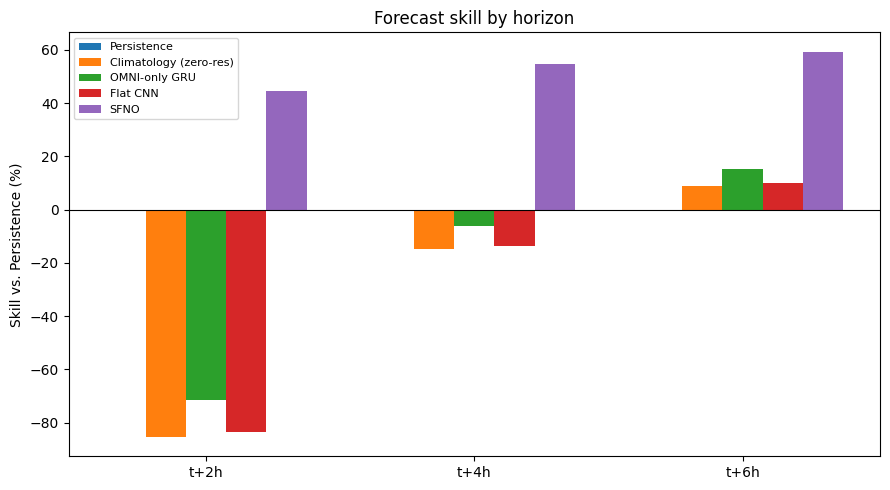

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(CONFIG['horizon_names']))
width = 0.15
for i, (name, res) in enumerate(RESULTS.items()):
    skill = 100 * (1 - res['rmse'] / persist_rmse)
    ax.bar(x + i * width, skill.numpy(), width, label=name)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(x + width * (len(RESULTS) - 1) / 2)
ax.set_xticklabels(CONFIG['horizon_names'])
ax.set_ylabel('Skill vs. Persistence (%)')
ax.set_title('Forecast skill by horizon')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## Cell 12 — Absolute-TEC comparison using Hayden's per-year climatology delivery

**Inspected `2025.npz` directly (uploaded to this chat) -- here's what that resolved, and the one
thing it didn't:**

- **Grid: (23, 45)** -- matches `CONFIG['H']`/`CONFIG['W']` exactly (also matches the
  `Conv2d(kernel_size=(23,45))` full-map kernel from the baselines notebook). Confirmed, not assumed.
- **Cadence: hourly**, full calendar year 2025-01-01 00:00 UTC through 2026-01-01 00:00 UTC
  inclusive (8,761 samples, 3600s spacing). Since the reformatted training data is 2hr-cadence,
  every sample timestamp needed for the join already exists in this file exactly -- no
  interpolation needed, just an exact-timestamp lookup.
- **Units: raw TECU**, not normalized -- values range 0 to ~182, mean ~26.5, always non-negative.
  Consistent with real physical TEC magnitudes, not the model's normalized residual scale. So
  reconstruction needs the model's residual de-normalized first
  (`pred_raw = pred_normalized * CONFIG['tec_std'] + CONFIG['tec_mean']`) before combining with
  this file's TECU values.
- **`input_fingerprint`: a single scalar string** (`'4a0308a2e4948b91'`, one value for the whole
  file), not a per-sample array -- it's a build/version identifier for the delivery, not a join
  key. Join against eval samples via `timestamps` directly, not fingerprint.

**Still genuinely unresolved: is `tec` the climatological reference (to *add to* residual
predictions) or the actual/reconstructed absolute TEC for that year (ground truth to score
*against*)?** Checked for evidence either way:
- Domain-mean TEC across 5 consecutive days (noon UTC) was fairly stable (37.3, 37.4, 40.9, 37.3,
  36.4) -- smoother than raw observations with storms would typically look, leaning toward
  "climatological reference."
- But a single fixed grid point swung much more (22→16→22→23→19→25 across consecutive days) --
  that's more likely just the ionospheric bulge's spatial pattern shifting day to day (normal, not
  necessarily storm noise), so this alone doesn't rule out either interpretation.
- Not decisive either way from the file's numbers alone -- this needs one direct answer, not
  another guess.

**One precise question would settle this for good:** *"Is `tec.npy` in the per-year climatology
delivery the IRI-model climatological baseline used to compute the residual training targets, or
is it the reconstructed/observed absolute TEC for that year?"*

`TEC_NPZ_ROLE` below gates which reconstruction path runs -- leave `'unknown'` (skips scoring)
until that question is answered, then set it to `'climatology'` or `'ground_truth'` accordingly.
Both paths are implemented below so switching is a one-line change, not a rewrite.


In [17]:
TEC_NPZ_ROLE = 'climatology'   # set to 'climatology' or 'ground_truth' once confirmed with Hayden
CLIMATOLOGY_DIR = "/content/drive/MyDrive/tec_data/climatology"   # adjust to actual Drive path

if TEC_NPZ_ROLE == 'unknown':
    print("Skipping absolute-TEC scoring -- TEC_NPZ_ROLE is 'unknown'.")
    print("See the markdown above for the one question that resolves this.")
else:
    import bisect

    def load_climatology_year(year):
        d = np.load(f"{CLIMATOLOGY_DIR}/{year}.npz")
        return d['tec'], d['timestamps']  # tec: (n_hours, H, W) TECU; timestamps: (n_hours,) unix sec

    _clim_cache = {}
    def climatology_lookup(unix_ts):
        """Exact-timestamp match (hourly file, 2hr-aligned queries -> always an exact hit)."""
        import datetime
        year = datetime.datetime.utcfromtimestamp(int(unix_ts)).year
        if year not in _clim_cache:
            _clim_cache[year] = load_climatology_year(year)
        tec_arr, ts_arr = _clim_cache[year]
        pos = bisect.bisect_left(ts_arr, int(unix_ts))
        if pos >= len(ts_arr) or ts_arr[pos] != int(unix_ts):
            raise KeyError(f"No exact climatology timestamp match for {unix_ts} (year {year})")
        return tec_arr[pos]   # (H, W), TECU

    @torch.no_grad()
    def evaluate_absolute_tec(model, loader, config, device, role):
        sum_sqerr = torch.zeros(config['n_horizons']); n = 0
        for batch in loader:
            tec_input  = batch['tec_input'].to(device)
            omni_input = batch['omni_input'].to(device)
            target     = batch['target'].to(device)          # normalized dTEC, ground truth
            timestamps = batch['timestamp']

            with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
                pred = model(tec_input, omni_input).float()

            pred_raw   = pred   * config['tec_std'] + config['tec_mean']   # de-normalize
            target_raw = target * config['tec_std'] + config['tec_mean']

            for b in range(tec_input.shape[0]):
                # each sample's climatology map is looked up per horizon in principle (timestamp +
                # horizon offset) -- using the window start time for all horizons here as a first
                # pass; refine to per-horizon offset timestamps if climatology res allows it.
                clim_map = torch.from_numpy(
                    climatology_lookup(int(timestamps[b]))
                ).to(device).float()

                if role == 'climatology':
                    true_abs = clim_map.unsqueeze(0) + target_raw[b]
                    pred_abs = clim_map.unsqueeze(0) + pred_raw[b]
                elif role == 'ground_truth':
                    # clim_map IS the ground truth absolute TEC at t0; derive the climatology
                    # baseline algebraically: climatology = absolute_TEC - true_dTEC
                    derived_clim = clim_map - target_raw[b, 0]   # uses horizon-0 target as an approx
                    true_abs = clim_map.unsqueeze(0).expand_as(target_raw[b])
                    pred_abs = derived_clim.unsqueeze(0) + pred_raw[b]
                else:
                    raise ValueError(role)

                sum_sqerr += ((pred_abs - true_abs) ** 2).mean(dim=[-1, -2]).cpu()
                n += 1

        return torch.sqrt(sum_sqerr / n)   # RMSE in TECU, per horizon

    abs_rmse = evaluate_absolute_tec(sfno_model, eval_loader, CONFIG, DEVICE, TEC_NPZ_ROLE)
    for i, hname in enumerate(CONFIG['horizon_names']):
        print(f"  {hname}: absolute-TEC RMSE = {abs_rmse[i]:.2f} TECU")


NotImplementedError: "baddbmm_cuda" not implemented for 'ComplexHalf'